# Wykorzystanie rozkładów macierzy do rozwiązywania oznaczonych układów równań

Poznane na wykładzie rozkłady (faktoryzacje) macierzy możemy wykorzystać do rozwiązywania układów równań liniowych. Dzięki wykorzystaniu specjalnych własności macierzy występujących w rozkładzie jesteśmy w stanie w łatwiejszy sposób odwrócić macierz i tym samym zminimalizować błąd.


**Zadanie 1.**

Rozważmy układ równań $Ax=b$, w którym:
* $A$ jest macierzą Hilberta o wymiarach 15x15.
* $A$ jest macierzą wartości losowych z przedziału $[0,100]$ o wymiarach 100x100,  1000x1000 i 1000000x1000000.
* $b$ jest wektorem wartości losowych, odpowiednio, o wymiarach 15x1, 100x1, 1000x1 i 1000000x1.

1. Oblicz współczynnik uwarunkowania macierzy $A$ i oceń jej uwarunkowanie.
2. Rozwiąż układ równań następującymi metodami:
    * z użyciem jawnej odwrotności $A$.
    * korzystając z rozkładu [LU](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lu.html) (uwaga na macierz permutacji!):
        * z wykorzystaniem odwrotności L i U.
        * z użyciem jedynie odwrotności i metody podstawiania wstecznego.
    * korzystając z rozkładu [QR](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html):
        * z wykorzystaniem odwrotności Q i R.
        * z użyciem jedynie odwrotności Q i metody podstawiania wstecznego.
    * za pomocą jednej z metod iteracyjnych z poprzedniego ćwiczenia.
    * za pomocą metody [`solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) z pakietu NumPy.
3. Porównaj otrzymane wyniki. W tym celu oblicz normy z residuuów otrzymanych dla każdego z rozwiązań. Którą z metod cechuje najwyższa dokladność?
4. Przeprowadź porównanie wydajności ww. metod. Zmierz czas wykonania każdej metody. Aby otrzymać bardziej sensowny wynik należy powtórzyć obliczenia w pętli (np. 100 lub 1000 razy) i uśrednić wynik. Do pomiaru czasu wykonania możesz wykorzystać pakiet `time`.
Wskazówka: Do rozwiązania układu z macierzą trójkątną możesz wykorzystać funkcję [`scipy.linalg.solve_triangular`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.solve_triangular.html).

        
        


In [2]:
import numpy as np
import scipy.linalg as la
import time

def solve_all_methods(A, b, label="", n_repeats=100):
    print(f"\n{'='*60}")
    print(f"Macierz: {label}, rozmiar: {A.shape}")
    print(f"{'='*60}")

    # 1. Współczynnik uwarunkowania
    cond = np.linalg.cond(A)
    print(f"Współczynnik uwarunkowania: {cond:.4e}")
    if cond < 1e3:
        print("  -> Dobrze uwarunkowana")
    elif cond < 1e10:
        print("  -> Umiarkowanie uwarunkowana")
    else:
        print("  -> ŹLE uwarunkowana (wyniki mogą być niedokładne!)")

    # Rozkłady (tylko raz, poza pętlą czasową)
    P, L, U = la.lu(A)
    Q, R = np.linalg.qr(A)

    results = {}
    times = {}

    # --- Metoda 1: jawna odwrotność ---
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        x = np.linalg.inv(A) @ b
    times["Jawna odwrotność"] = (time.perf_counter() - t0) / n_repeats
    results["Jawna odwrotność"] = x

    # --- Metoda 2: LU z odwrotnościami L i U ---
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        Pb = P.T @ b
        x = np.linalg.inv(U) @ np.linalg.inv(L) @ Pb
    times["LU (inv L i U)"] = (time.perf_counter() - t0) / n_repeats
    results["LU (inv L i U)"] = x

    # --- Metoda 3: LU z podstawianiem wstecznym ---
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        Pb = P.T @ b
        y = la.solve_triangular(L, Pb, lower=True)
        x = la.solve_triangular(U, y, lower=False)
    times["LU (podstawianie)"] = (time.perf_counter() - t0) / n_repeats
    results["LU (podstawianie)"] = x

    # --- Metoda 4: QR z odwrotnościami Q i R ---
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        x = np.linalg.inv(R) @ np.linalg.inv(Q) @ b
    times["QR (inv Q i R)"] = (time.perf_counter() - t0) / n_repeats
    results["QR (inv Q i R)"] = x

    # --- Metoda 5: QR z Q^T i podstawianiem wstecznym ---
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        QtB = Q.T @ b
        x = la.solve_triangular(R, QtB, lower=False)
    times["QR (Q^T + podstawianie)"] = (time.perf_counter() - t0) / n_repeats
    results["QR (Q^T + podstawianie)"] = x

    # --- Metoda 6: iteracyjna ---
    def gauss_seidel(A, b, tol=1e-10, max_iter=1000):
        n = len(b)
        x = np.zeros(n)
        for _ in range(max_iter):
            x_new = np.copy(x)
            for i in range(n):
                s1 = np.dot(A[i, :i], x_new[:i])
                s2 = np.dot(A[i, i+1:], x[i+1:])
                if abs(A[i, i]) < 1e-15:
                    continue
                x_new[i] = (b[i] - s1 - s2) / A[i, i]
            if np.linalg.norm(x_new - x) < tol:
                return x_new
            x = x_new
        return x

    # Gauss-Seidel tylko dla małych macierzy 
    if A.shape[0] <= 100:
        reps_gs = max(1, n_repeats // 10)
        t0 = time.perf_counter()
        for _ in range(reps_gs):
            x = gauss_seidel(A, b)
        times["Gauss-Seidel"] = (time.perf_counter() - t0) / reps_gs
        results["Gauss-Seidel"] = x
    else:
        print("  (Gauss-Seidel pominięty dla dużych macierzy)")

    # --- Metoda 7: numpy.linalg.solve ---
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        x = np.linalg.solve(A, b)
    times["numpy.linalg.solve"] = (time.perf_counter() - t0) / n_repeats
    results["numpy.linalg.solve"] = x

    # --- Porównanie residuów ---
    print(f"\n{'Metoda':<30} {'||residuum||':>15} {'Czas [ms]':>12}")
    print("-" * 60)
    x_ref = results["numpy.linalg.solve"]
    for name, x in results.items():
        residuum = np.linalg.norm(A @ x - b)
        t_ms = times[name] * 1000
        print(f"{name:<30} {residuum:>15.6e} {t_ms:>12.4f}")

    
    best = min(results.items(), key=lambda kv: np.linalg.norm(A @ kv[1] - b))
    print(f"\nNajwyższa dokładność: '{best[0]}'")



# Macierz Hilberta 15x15
A_hilbert = la.hilbert(15)
b_hilbert = np.random.rand(15)
solve_all_methods(A_hilbert, b_hilbert, label="Hilbert 15x15", n_repeats=500)

# Macierze losowe — rozmiar 100x100
np.random.seed(42)
A100 = np.random.uniform(0, 100, (100, 100))
b100 = np.random.rand(100)
solve_all_methods(A100, b100, label="Losowa 100x100", n_repeats=200)

# Macierze losowe — rozmiar 1000x1000
A1000 = np.random.uniform(0, 100, (1000, 1000))
b1000 = np.random.rand(1000)
solve_all_methods(A1000, b1000, label="Losowa 1000x1000", n_repeats=10)

# Macierz 1 000 000 x 1 000 000 jest zbyt duża dla RAM —
# pokazujemy to informacyjnie:
print("\n" + "="*60)
print("Macierz 1000000x1000000: niemożliwa do przechowania w RAM")
print("(wymagałaby ~8 TB pamięci).")
print("="*60)


Macierz: Hilbert 15x15, rozmiar: (15, 15)
Współczynnik uwarunkowania: 3.3659e+17
  -> ŹLE uwarunkowana (wyniki mogą być niedokładne!)

Metoda                            ||residuum||    Czas [ms]
------------------------------------------------------------
Jawna odwrotność                  2.906757e+00       0.1820
LU (inv L i U)                    8.623963e+01       0.3669
LU (podstawianie)                 7.815797e+01       0.0166
QR (inv Q i R)                    1.725054e+00       0.3474
QR (Q^T + podstawianie)           1.607414e+00       0.0075
Gauss-Seidel                      8.393987e-01      28.4418
numpy.linalg.solve                4.999992e-01       0.1383

Najwyższa dokładność: 'numpy.linalg.solve'

Macierz: Losowa 100x100, rozmiar: (100, 100)
Współczynnik uwarunkowania: 2.0930e+03
  -> Umiarkowanie uwarunkowana

Metoda                            ||residuum||    Czas [ms]
------------------------------------------------------------
Jawna odwrotność                  1.29894

# Interpolacja

**Zadanie 2.**

Przeprowadź interpolacje poniższych funkcji $f(x)$ za pomocą wielomianów interpolacyjnych Lagrange'a ([`scipy.interpolate.lagrange`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.lagrange.html)). Stwórz wykresy funkcji interpolacyjnych i zaznacz na nich punkty, w ktorych dokonano oceny wartości funkcji.

Pierwsza funkcja:

* $f(0) = 1$,
* $f(0.25) = 1.64872$,
* $f(0.5) = 2.71828$,
* $f(0.75) = 4.48169.$

Oblicz $f(0.43)$.

Druga funkcja:

* $f_2(0.1) = 0.62049958$,
* $f_2(0.2) = -0.28398668$,
* $f_2(0.3) = 0.00660095$,
* $f_2(0.4) = 0.24842440$. 

Oblicz $f_2(0.25)$.

Funkcja 1: f(0.43) ≈ 2.360605


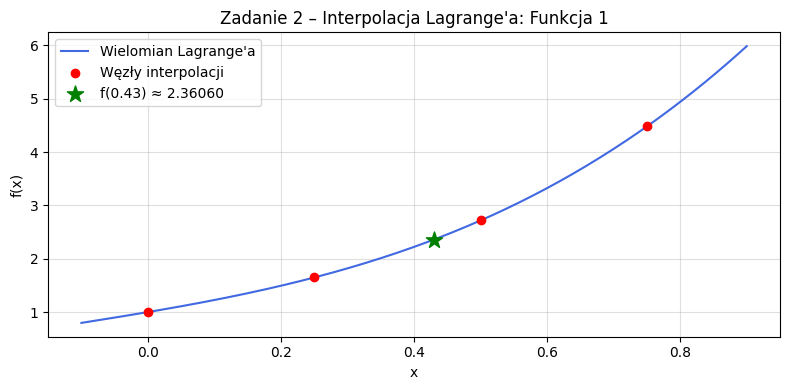

Zapisano: zadanie2_f1.png
Funkcja 2: f2(0.25) ≈ -0.210337


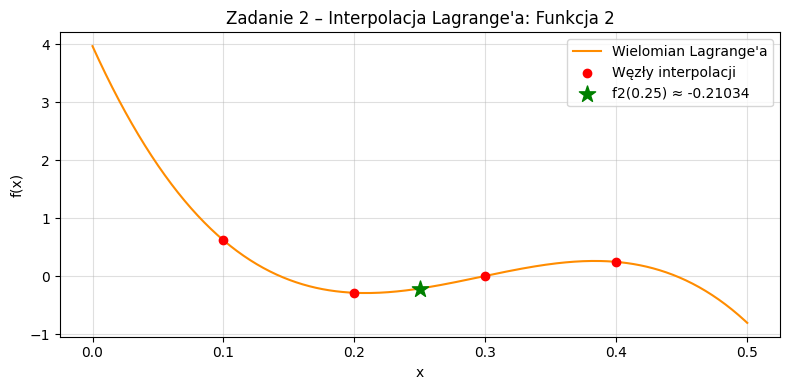

Zapisano: zadanie2_f2.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange

# ============================================================
# Funkcja 1: f(x) ≈ e^(2x) (wartości w węzłach)
# ============================================================
x1 = np.array([0.0, 0.25, 0.5, 0.75])
y1 = np.array([1.0, 1.64872, 2.71828, 4.48169])

poly1 = lagrange(x1, y1)
val1 = poly1(0.43)
print(f"Funkcja 1: f(0.43) ≈ {val1:.6f}")

x1_plot = np.linspace(-0.1, 0.9, 300)
plt.figure(figsize=(8, 4))
plt.plot(x1_plot, poly1(x1_plot), label="Wielomian Lagrange'a", color="royalblue")
plt.scatter(x1, y1, color="red", zorder=5, label="Węzły interpolacji")
plt.scatter([0.43], [val1], color="green", zorder=6, marker="*", s=150, label=f"f(0.43) ≈ {val1:.5f}")
plt.title("Zadanie 2 – Interpolacja Lagrange'a: Funkcja 1")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("zadanie2_f1.png", dpi=150)
plt.show()
print("Zapisano: zadanie2_f1.png")

# ============================================================
# Funkcja 2
# ============================================================
x2 = np.array([0.1, 0.2, 0.3, 0.4])
y2 = np.array([0.62049958, -0.28398668, 0.00660095, 0.24842440])

poly2 = lagrange(x2, y2)
val2 = poly2(0.25)
print(f"Funkcja 2: f2(0.25) ≈ {val2:.6f}")

x2_plot = np.linspace(0.0, 0.5, 300)
plt.figure(figsize=(8, 4))
plt.plot(x2_plot, poly2(x2_plot), label="Wielomian Lagrange'a", color="darkorange")
plt.scatter(x2, y2, color="red", zorder=5, label="Węzły interpolacji")
plt.scatter([0.25], [val2], color="green", zorder=6, marker="*", s=150, label=f"f2(0.25) ≈ {val2:.5f}")
plt.title("Zadanie 2 – Interpolacja Lagrange'a: Funkcja 2")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("zadanie2_f2.png", dpi=150)
plt.show()
print("Zapisano: zadanie2_f2.png")

***Zadanie 3.***

Rozważmy funkcję $f(x)=\frac{1}{25x^2+1}$. 

Przeprowadź interpolacje funkcji $f$ w przedziale $[-2,2]$ wielomianem Lagrange'a oraz funkcjami sklejanymi 3 stopnia w:
- 21 równoodległych węzłach,
- 21 węzłach [Czebyszewa](https://pl.wikipedia.org/wiki/Węzły_Czebyszewa).

**Wskazówka** Interpolację funkcjami sklejanymi możesz przeprowadzić za pomocą funkcji [`interp1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d).

Umieść wielomian interpolacyjny, oryginalną funkcję $f$ oraz węzly interpolacyjne na wspólnym wykresie (jeden wykres dla metody Lagrange'a oraz jeden dla funkcji sklejanych). Porównaj otrzymane rezultaty. Przeprowadź te same działania dla przedziału $x\in[-5,5]$. Jakie problemy możesz zauważyć na otrzymanych wykresach?

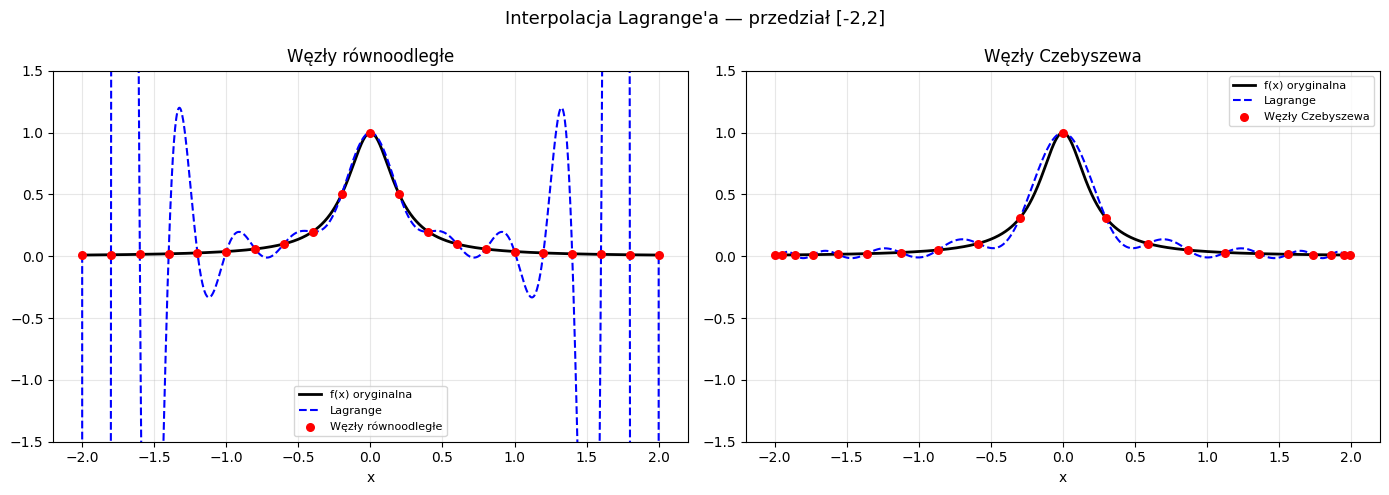

Zapisano: zadanie3_lagrange_-2_2.png


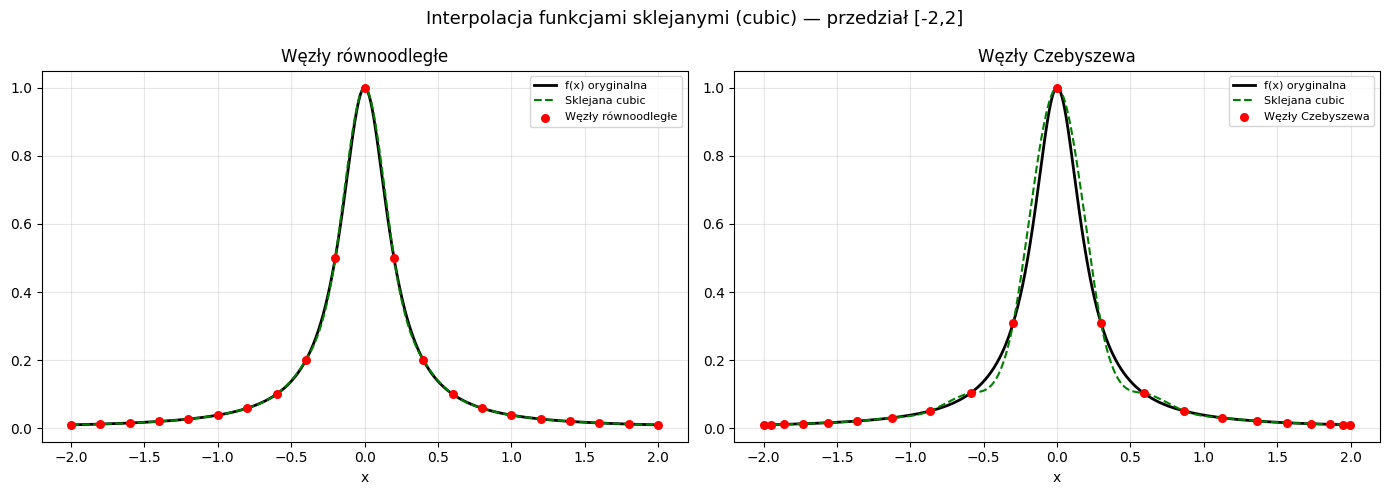

Zapisano: zadanie3_spline_-2_2.png


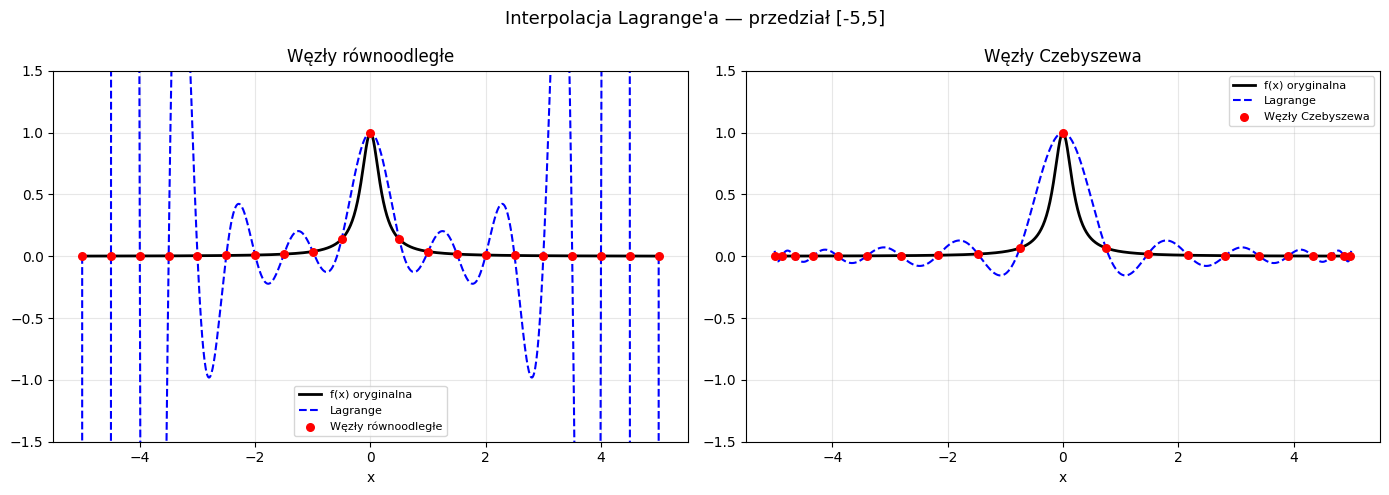

Zapisano: zadanie3_lagrange_-5_5.png


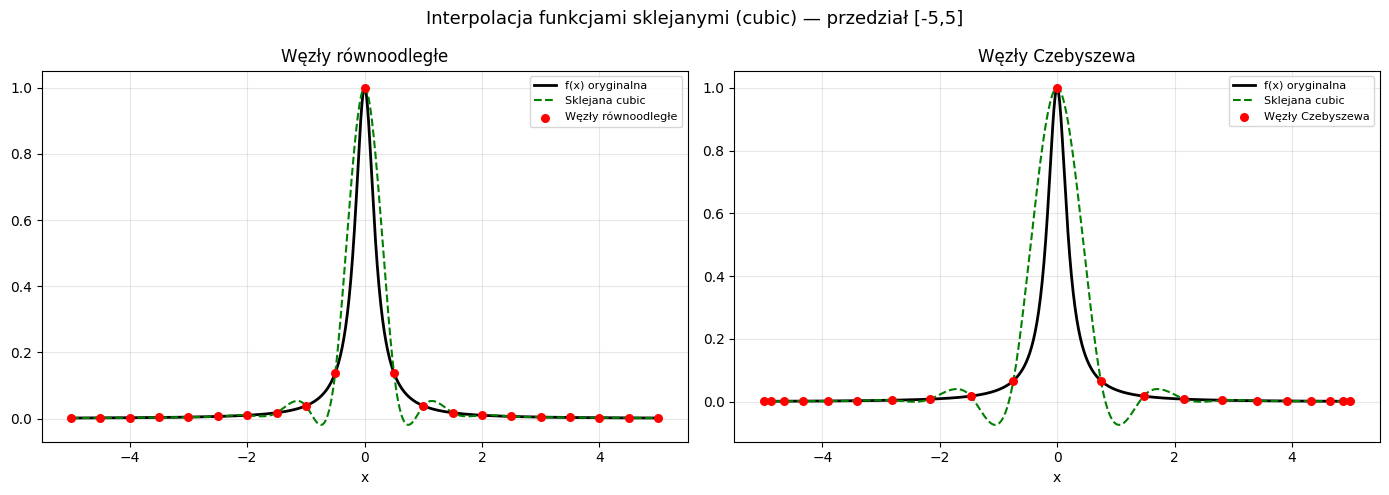

Zapisano: zadanie3_spline_-5_5.png

OBSERWACJE:
- Lagrange + węzły równoodległe: efekt Runge'go — silne oscylacje na brzegach przedziału.
- Lagrange + węzły Czebyszewa: znacznie lepiej, oscylacje mocno zredukowane.
- Funkcje sklejane: dla obu rodzajów węzłów bardzo dobra dokładność, bez oscylacji.
- Dla przedziału [-5,5] efekt Runge'go jest dramatycznie widoczny dla Lagrange z węzłami równoodległymi.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, interp1d
import warnings
warnings.filterwarnings("ignore")

def runge(x):
    return 1.0 / (25 * x**2 + 1)

def chebyshev_nodes(a, b, n):
    """n węzłów Czebyszewa w przedziale [a, b]"""
    k = np.arange(1, n + 1)
    return 0.5 * (a + b) + 0.5 * (b - a) * np.cos((2*k - 1) * np.pi / (2*n))

N = 21  # liczba węzłów

for interval_label, a, b in [("[-2,2]", -2, 2), ("[-5,5]", -5, 5)]:
    x_dense = np.linspace(a, b, 1000)
    y_true = runge(x_dense)

    # Węzły
    x_eq = np.linspace(a, b, N)               
    x_ch = np.sort(chebyshev_nodes(a, b, N))  

    y_eq = runge(x_eq)
    y_ch = runge(x_ch)

    # === Lagrange ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Interpolacja Lagrange'a — przedział {interval_label}", fontsize=13)

    for ax, x_nodes, y_nodes, node_label in zip(
        axes,
        [x_eq, x_ch],
        [y_eq, y_ch],
        ["Węzły równoodległe", "Węzły Czebyszewa"]
    ):
        poly = lagrange(x_nodes, y_nodes)
        y_interp = poly(x_dense)

        ax.plot(x_dense, y_true, "k-", lw=2, label="f(x) oryginalna")
        ax.plot(x_dense, y_interp, "b--", lw=1.5, label="Lagrange")
        ax.scatter(x_nodes, y_nodes, color="red", zorder=5, s=30, label=node_label)
        ax.set_ylim(-1.5, 1.5)
        ax.set_title(node_label)
        ax.set_xlabel("x")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"zadanie3_lagrange_{interval_label.replace('[','').replace(']','').replace(',','_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Zapisano: {fname}")

    # === Funkcje sklejane (cubic spline) ===
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Interpolacja funkcjami sklejanymi (cubic) — przedział {interval_label}", fontsize=13)

    for ax, x_nodes, y_nodes, node_label in zip(
        axes,
        [x_eq, x_ch],
        [y_eq, y_ch],
        ["Węzły równoodległe", "Węzły Czebyszewa"]
    ):
        # fill_value="extrapolate" pozwala ewaluować poza zakresem węzłów
        # (węzły Czebyszewa nie sięgają dokładnie do krańców przedziału)
        spline = interp1d(x_nodes, y_nodes, kind="cubic",
                          bounds_error=False, fill_value="extrapolate")
        y_interp = spline(x_dense)

        ax.plot(x_dense, y_true, "k-", lw=2, label="f(x) oryginalna")
        ax.plot(x_dense, y_interp, "g--", lw=1.5, label="Sklejana cubic")
        ax.scatter(x_nodes, y_nodes, color="red", zorder=5, s=30, label=node_label)
        ax.set_title(node_label)
        ax.set_xlabel("x")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"zadanie3_spline_{interval_label.replace('[','').replace(']','').replace(',','_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Zapisano: {fname}")

print("""
OBSERWACJE:
- Lagrange + węzły równoodległe: efekt Runge'go — silne oscylacje na brzegach przedziału.
- Lagrange + węzły Czebyszewa: znacznie lepiej, oscylacje mocno zredukowane.
- Funkcje sklejane: dla obu rodzajów węzłów bardzo dobra dokładność, bez oscylacji.
- Dla przedziału [-5,5] efekt Runge'go jest dramatycznie widoczny dla Lagrange z węzłami równoodległymi.
""")

***Zadanie 4.***

Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

**Zadanie dla zainteresowanych programowaniem funkcyjnym w Pythonie**

Stwórz funkcję znajdującą wielomian interpolacyjny metodą Lagrange'a. Funkcja powinna przyjmować dwie listy:
* listę argumentów ($x$-ów)
* listę wartości ($y$-ów).  


Po wykonaniu obliczeń funkcja powinna zwracać wielomian w postaci obiektu typu **funkcja** (a nie `numpy.Polynomial`).

**Wskazówka** Wykorzystaj wyrażenia *lambda*. Dla ułatwienia możesz się też posłużyć pakietami `operator` i `functools`.
